In [340]:
# https://platform.olimpiada-ai.ro/ro/problems/190

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [341]:
data = pd.read_csv("/kaggle/input/datasets/abukanabek/battlefield-recon/data.csv")
data.shape

(5023, 4)

In [342]:
data.head()

,ID,x,y,Team
0,2472,8.631817,45.333395,1
1,4081,8.090193,45.560999,0
2,2643,8.447465,45.786570,0
3,2719,8.253795,45.495731,0
4,4975,8.140001,45.609608,0


In [343]:
data['Team'].value_counts()

Team
1    3183
0    1840
Name: count, dtype: int64

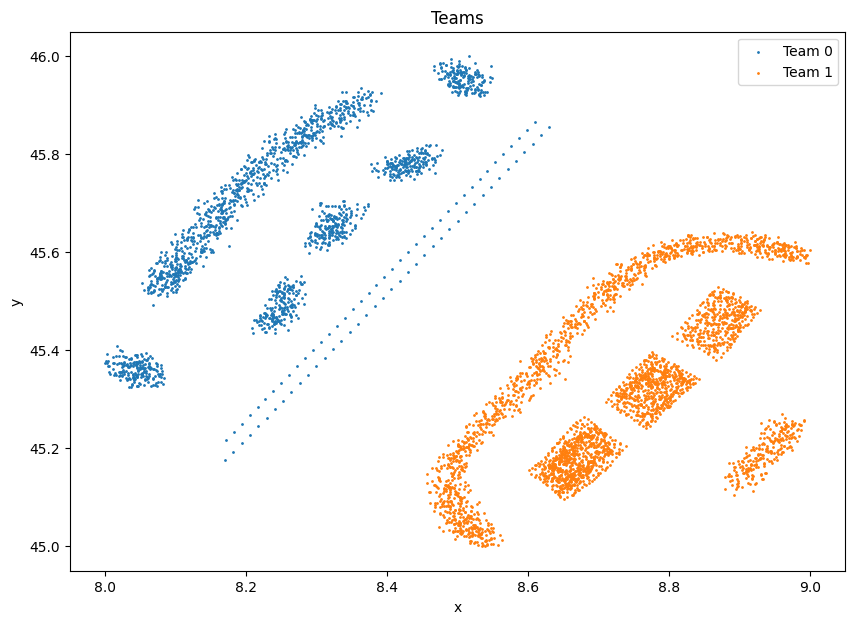

In [344]:
plt.figure(figsize=(10, 7))
plt.title('Teams')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(data[data['Team']==0]['x'], data[data['Team']==0]['y'], s=1, label='Team 0')
plt.scatter(data[data['Team']==1]['x'], data[data['Team']==1]['y'], s=1, label='Team 1')
plt.legend()
plt.show()

In [345]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data[['x', 'y']] = scaler.fit_transform(data[['x', 'y']])

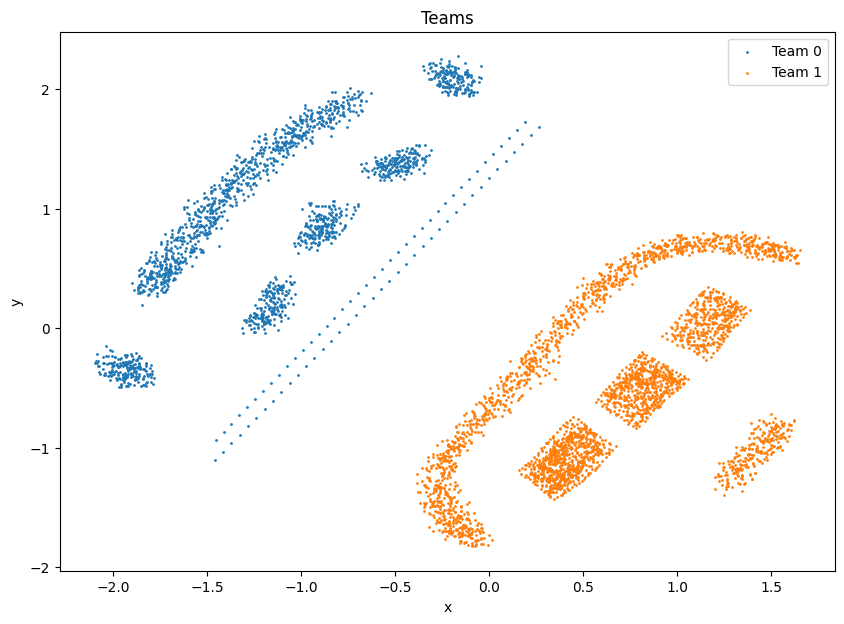

In [346]:
plt.figure(figsize=(10, 7))
plt.title('Teams')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(data[data['Team']==0]['x'], data[data['Team']==0]['y'], s=1, label='Team 0')
plt.scatter(data[data['Team']==1]['x'], data[data['Team']==1]['y'], s=1, label='Team 1')
plt.legend()
plt.show()

In [347]:
from sklearn.cluster import DBSCAN

clusterer = DBSCAN(eps=0.16)

clusters = clusterer.fit_predict(data[['x', 'y']])
clusters = np.where(clusters == -1, 11, clusters)

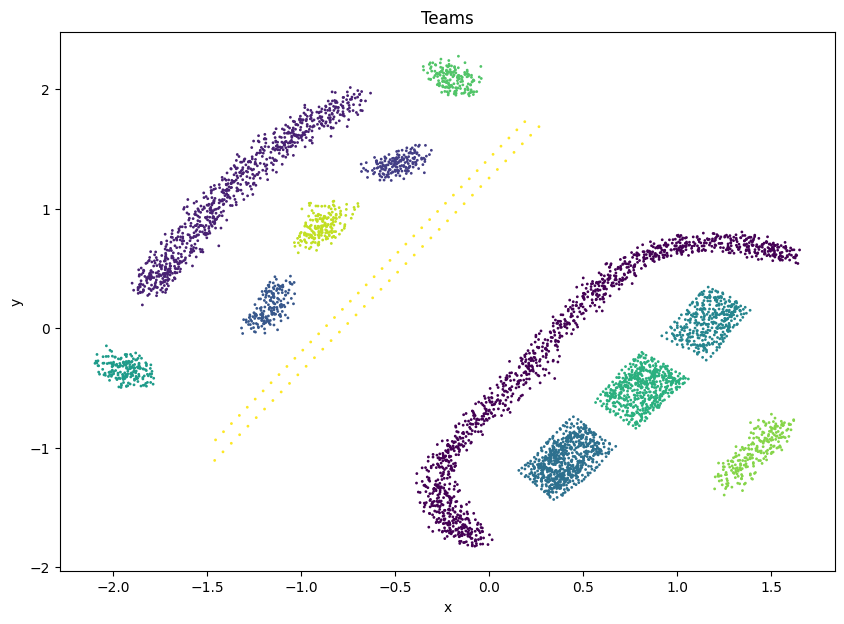

In [348]:
plt.figure(figsize=(10, 7))
plt.title('Teams')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(data['x'], data['y'], c=clusters, s=1)
plt.show()

In [349]:
pd.Series(clusters).value_counts().sort_index()

0     1285
1      826
2      182
3      189
4      731
5      376
6      193
7      556
8      174
9      235
10     196
11      80
Name: count, dtype: int64

In [350]:
subm = pd.DataFrame({
    'subtaskID': [1] * len(data) + [2] * len(data),
    'datapointID': data['ID'].tolist() + data['ID'].tolist(),
    'answer': (clusters == 11).astype(int).tolist() + clusters.tolist()
})

subm.to_csv("submission.csv", index=False)
subm

,subtaskID,datapointID,answer
0,1,2472,0
1,1,4081,0
2,1,2643,0
3,1,2719,0
4,1,4975,0
...,...,...,...
10041,2,2415,10
10042,2,5006,0
10043,2,2705,0
10044,2,2177,1
